# Scenario I — Xception (Notebook 1: TPE Search)
## Melanoma Classification via Bayesian Optimisation with Tree-structured Parzen Estimator (TPE)

Notebook ini menjalankan **TPE Hyperparameter Search** untuk Xception menggunakan Optuna `TPESampler` (multivariate, 30 trial × 12 epoch). Notebook ini adalah **Bagian 1 dari 2** — hasilnya disimpan ke `tpe_xception.json` dan dimuat oleh **NB2** untuk final training.

Xception menggunakan input 299×299 dan merupakan arsitektur terberat di pipeline ini, sehingga TPE search dan final training dipisah menjadi dua notebook untuk menghindari timeout ~9 jam Kaggle.


## 0. Instalasi

Cell berikut berisi skrip instalasi PyTorch versi CUDA 11.8 yang dinonaktifkan (di-comment) karena environment Kaggle biasanya sudah menyertakan versi yang kompatibel. Aktifkan hanya jika versi PyTorch yang terinstal tidak sesuai dengan GPU yang digunakan, lalu **restart kernel** sebelum melanjutkan.


In [1]:
# import subprocess, sys

# # Install PyTorch cu118 (compatible with compute capability 6.0 / P100)
# subprocess.check_call([
#     sys.executable, '-m', 'pip', 'install',
#     'torch==2.5.1+cu118',
#     'torchvision==0.20.1+cu118',
#     '--index-url', 'https://download.pytorch.org/whl/cu118',
#     '-q',
#     '--root-user-action=ignore',
#     '--disable-pip-version-check'
# ])

# print('Installation complete')
# print('IMPORTANT: restart the kernel before proceeding')

## 1. Import, Seed & Device

Mengimpor seluruh library yang dibutuhkan, lalu mengunci semua sumber randomness (`random`, `numpy`, `torch`) ke `SEED = 42` agar eksperimen dapat direproduksi. Deteksi device dilakukan otomatis — GPU digunakan jika tersedia, beserta Automatic Mixed Precision (AMP) untuk efisiensi memori.


In [2]:
import os, json, time, warnings, random, math
from pathlib import Path
from copy import deepcopy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import timm
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()

print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'USE_AMP : {USE_AMP}')
print(f'torch   : {torch.__version__}')
print(f'timm    : {timm.__version__}')
print(f'optuna  : {optuna.__version__}')


Device  : cuda
GPU     : Tesla P100-PCIE-16GB
VRAM    : 17.1 GB
USE_AMP : True
torch   : 2.5.1+cu118
timm    : 1.0.26
optuna  : 4.8.0


## 2. Konfigurasi

Mendefinisikan seluruh konstanta eksperimen dalam satu tempat:

- **Path dataset**: DS1 (Kaggle — bhaveshmittal) dan DS2 (Kaggle — hasnainjaved) beserta direktori output dan checkpoint.
- **Hyperparameter pelatihan**: jumlah kelas, jumlah worker DataLoader, gradient clipping, dan jumlah langkah TTA.
- **Konfigurasi TPE**: 30 trial × 12 epoch per trial, 10 startup trials random sebelum TPE aktif. Budget ini disesuaikan dengan batas ~9 jam Kaggle untuk Xception (299×299 input).
- **Jadwal unfreezing** (`CNN_UNFREEZE`): dari `frozen` (head saja) hingga `full` (seluruh backbone) di epoch 18.
- **Baseline referensi** (`PAPER_REF`): metrik dari paper acuan untuk perbandingan hasil akhir.


In [3]:
DS1_BASE  = Path('/kaggle/input/datasets/bhaveshmittal/melanoma-cancer-dataset')
DS1_TRAIN = DS1_BASE / 'train'
DS1_TEST  = DS1_BASE / 'test'
DS2_BASE  = Path('/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images')
DS2_TEST  = DS2_BASE / 'melanoma_cancer_dataset' / 'test'
OUTPUT_DIR = Path('/kaggle/working/full_pipeline_results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR   = OUTPUT_DIR / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

NUM_CLASSES  = 2
NUM_WORKERS  = 4
GRAD_CLIP    = 1.0
TTA_STEPS    = 10

N_TRIALS        = 30
TPE_EPOCHS      = 12
TPE_ES_PAT      = 3
TPE_WARMUP_TR   = 10
FINAL_EPOCHS    = 35
VIT_FINAL_EP    = 30
ENS_TRIALS      = 100

VIT_MODEL_NAME  = 'vit_small_patch16_224'
VIT_IMG_SIZE    = 224

CNN_UNFREEZE = {
    1  : 'frozen',
    5  : 'last_block',
    10 : 'last_2_blocks',
    18 : 'full',
}

ARCH_CONFIGS = {
    'densenet121': {
        'label'            : 'DenseNet-121',
        'img_size'         : 224,
        'unfreeze_schedule': CNN_UNFREEZE,
    },
    'inception_v3': {
        'label'            : 'InceptionV3',
        'img_size'         : 299,
        'unfreeze_schedule': CNN_UNFREEZE,
    },
    'xception': {
        'label'            : 'Xception',
        'img_size'         : 299,
        'unfreeze_schedule': CNN_UNFREEZE,
    },
}

MODEL_LABELS = {
    'densenet121'  : 'DenseNet-121',
    'inception_v3' : 'InceptionV3',
    'xception'     : 'Xception',
    'vit_scratch'  : 'ViT-Pretrained',
}

PAPER_REF = {
    'DenseNet-121'    : {'accuracy':0.9450, 'precision':0.9390,
                          'recall':0.9504,   'f1':0.9447},
    'InceptionV3'     : {'accuracy':0.9120, 'precision':0.9320,
                          'recall':0.8962,   'f1':0.9137},
    'Xception'        : {'accuracy':0.9380, 'precision':0.9300,
                          'recall':0.9451,   'f1':0.9375},
    'ViT-Pretrained'  : {'accuracy':0.8825, 'precision':0.9050,
                          'recall':0.8660,   'f1':0.8850},
    'Ensemble'        : {'accuracy':0.9525, 'precision':0.9420,
                          'recall':0.9622,   'f1':0.9520},
}

print('Configuration loaded successfully')
print(f'  N_TRIALS     = {N_TRIALS}  (was 15)')
print(f'  TPE_EPOCHS   = {TPE_EPOCHS}  (was 8)')
print(f'  TPE_ES_PAT   = {TPE_ES_PAT}  (was 2)')
print(f'  FINAL_EPOCHS = {FINAL_EPOCHS}  (was 30)')
print(f'  VIT_FINAL_EP = {VIT_FINAL_EP}  (was 40)')
print(f'  ENS_TRIALS   = {ENS_TRIALS}  (was 30)')
print(f'  ViT model    = {VIT_MODEL_NAME}  (was ViT-B/16 from scratch)')
print(f'  Unfreeze full at epoch {max(CNN_UNFREEZE.keys())} of {FINAL_EPOCHS}'
      f'  → {FINAL_EPOCHS - max(CNN_UNFREEZE.keys())} epoch full fine-tuning  (was 8)')
print()
print('Baseline Paper Reference:')
print(f'{"Model":<18} {"Accuracy":>10} {"Recall":>8} {"F1":>8}')
print('-' * 46)
for model, vals in PAPER_REF.items():
    print(f'{model:<18} {vals["accuracy"]:>10.2%} '
          f'{vals["recall"]:>8.2%} {vals["f1"]:>8.2%}')

Configuration loaded successfully
  N_TRIALS     = 30  (was 15)
  TPE_EPOCHS   = 12  (was 8)
  TPE_ES_PAT   = 3  (was 2)
  FINAL_EPOCHS = 35  (was 30)
  VIT_FINAL_EP = 30  (was 40)
  ENS_TRIALS   = 100  (was 30)
  ViT model    = vit_small_patch16_224  (was ViT-B/16 from scratch)
  Unfreeze full at epoch 18 of 35  → 17 epoch full fine-tuning  (was 8)

Baseline Paper Reference:
Model                Accuracy   Recall       F1
----------------------------------------------
DenseNet-121           94.50%   95.04%   94.47%
InceptionV3            91.20%   89.62%   91.37%
Xception               93.80%   94.51%   93.75%
ViT-Pretrained         88.25%   86.60%   88.50%
Ensemble               95.25%   96.22%   95.20%


## 3. Data Pipeline

Mendefinisikan dua fungsi utama:

**`get_transforms(split, img_size)`** — augmentasi berbeda per mode:
- `train`: augmentasi penuh (crop, flip, rotasi, color jitter, affine, grayscale, random erasing) untuk regularisasi.
- `tta` *(Test-Time Augmentation)*: augmentasi ringan yang diaplikasikan berulang saat inferensi untuk meningkatkan stabilitas prediksi.
- `val/test`: hanya resize dan normalisasi ImageNet — tanpa augmentasi.

**`build_dataloaders(batch_size, img_size)`** — membangun DataLoader untuk train, validation, dan test:
- Dataset dibagi stratified (85% train / 15% val) agar distribusi kelas tetap proporsional.
- `WeightedRandomSampler` digunakan dengan bobot invers-sqrt frekuensi kelas. Ukuran sampler digandakan (`len(sw) × 2`) agar kelas minoritas mendapat representasi yang cukup di setiap epoch.


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_transforms(split, img_size):
    if split == 'train':
        return transforms.Compose([
            transforms.Resize((img_size + 24, img_size + 24)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(25),
            transforms.ColorJitter(0.15, 0.15, 0.15, 0.08),
            transforms.RandomAffine(
                0, translate=(0.1, 0.1),
                scale=(0.85, 1.15), shear=5),
            transforms.RandomGrayscale(p=0.05),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            transforms.RandomErasing(p=0.15, scale=(0.02, 0.1)),
        ])
    elif split == 'tta':
        return transforms.Compose([
            transforms.Resize((img_size + 16, img_size + 16)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

def build_dataloaders(batch_size, img_size, val_split=0.15):
    full_ds = ImageFolder(
        DS1_TRAIN, transform=get_transforms('train', img_size))
    targets = [s[1] for s in full_ds.samples]
    cc      = [targets.count(i) for i in range(NUM_CLASSES)]

    tr_idx, vl_idx = train_test_split(
        range(len(full_ds)), test_size=val_split,
        stratify=targets, random_state=SEED)

    tr_ds   = Subset(full_ds, tr_idx)
    vl_base = ImageFolder(
        DS1_TRAIN, transform=get_transforms('val', img_size))
    vl_ds   = Subset(vl_base, vl_idx)

    tr_tgt   = np.array(targets)[tr_idx]
    class_cnt = np.bincount(tr_tgt)
    class_w  = 1.0 / np.sqrt(class_cnt.astype(float))
    class_w  = class_w / class_w.sum() * len(class_cnt)
    sw       = class_w[tr_tgt]
    smp      = WeightedRandomSampler(
        torch.DoubleTensor(sw), len(sw) * 2, replacement=True) # type: ignore

    tr_ld = DataLoader(
        tr_ds, batch_size, sampler=smp,
        num_workers=NUM_WORKERS, pin_memory=True)
    vl_ld = DataLoader(
        vl_ds, batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True)
    te_ds = ImageFolder(
        DS1_TEST, transform=get_transforms('test', img_size))
    te_ld = DataLoader(
        te_ds, 32, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True)

    return tr_ld, vl_ld, te_ld, full_ds.classes, cc

_, _, _, CLASS_NAMES, _ = build_dataloaders(32, 224)
print(f'Class names : {CLASS_NAMES}')

Class names : ['Benign', 'Malignant']


## 4. Model Factory

Mendefinisikan semua komponen yang dibutuhkan untuk membangun dan mengonfigurasi model:

- **`CNNWithHead`**: wrapper di atas backbone timm yang mengganti head default dengan head dua-lapisan (`Linear → BN → GELU → Dropout → Linear`), memberikan kapasitas adaptasi lebih besar.
- **`build_cnn`**: membuat CNN pretrained dengan `num_classes=0` (timm mengembalikan fitur mentah tanpa head klasifikasi) lalu menyambungkan `CNNWithHead`.
- **`apply_freeze` / `progressive_unfreeze`**: mengontrol parameter mana yang trainable sesuai strategi (`frozen`, `last_block`, `last_2_blocks`, `full`). Parameter afine normalisasi (BatchNorm: weight & bias) sengaja tidak dibekukan di semua fase karena membantu kalibrasi ulang distribusi aktivasi (*partial fine-tuning*, Li et al. 2017).
- **`build_optimizer`**: membangun Adam/AdamW/Adamax. Jika `layer_decay` diberikan, menerapkan *Layer-wise LR Decay* (LLRD) untuk ViT.
- **`FocalLoss`**: loss alternatif yang memberi bobot lebih besar pada sampel sulit. Menggunakan pembobotan *Effective Number of Samples* (formula `(1 - β^n) / (1 - β)`) yang lebih superior dari inverse-frequency murni.
- **`build_vit_pretrained`**: membangun ViT-Small/16 pretrained dengan head dua-lapisan khusus.


In [5]:

class CNNWithHead(nn.Module):
    """CNN wrapper with custom head: GAP → BN → GELU → Dropout → Linear.
    Provides greater adaptation capacity than the default timm head.
    """
    def __init__(self, backbone, n_features, dropout, num_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Linear(n_features, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )
        self._init_head()

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.head(self.backbone(x))

def build_cnn(arch_name, dropout):
    """Build a pretrained CNN with a 512-dim custom classification head."""
    backbone   = timm.create_model(
        arch_name, pretrained=True,
        drop_rate=dropout, num_classes=0)
    n_features = backbone.num_features
    return CNNWithHead(backbone, n_features, dropout, NUM_CLASSES)

def apply_freeze(model, strategy):
    if isinstance(model, CNNWithHead):
        params = list(model.backbone.named_parameters())
        for p in model.head.parameters():
            p.requires_grad_(True)
    else:
        params = list(model.named_parameters())

    total = len(params)
    for _, p in params:
        p.requires_grad_(False)

    for name, p in params:
        if any(k in name for k in ('head', 'classifier', 'fc', 'last_linear', 'norm')):
            p.requires_grad_(True)

    if strategy == 'last_block':
        for i, (_, p) in enumerate(params):
            if i >= int(total * 0.85):
                p.requires_grad_(True)
    elif strategy == 'last_2_blocks':
        for i, (_, p) in enumerate(params):
            if i >= int(total * 0.70):
                p.requires_grad_(True)
    elif strategy == 'full':
        for _, p in params:
            p.requires_grad_(True)
        if isinstance(model, CNNWithHead):
            for p in model.head.parameters():
                p.requires_grad_(True)

    tr  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    tot = sum(p.numel() for p in model.parameters())
    return model, tr, tot

def progressive_unfreeze(model, epoch, schedule):
    strategy = 'frozen'
    for ep, strat in sorted(schedule.items()):
        if epoch >= ep:
            strategy = strat
    model, tr, _ = apply_freeze(model, strategy)
    return model, strategy, tr

def build_optimizer(model, opt_name, lr, wd, layer_decay=None):
    """Build optimizer. If layer_decay is provided, applies LLRD for ViT."""
    if layer_decay is not None and hasattr(model, 'blocks'):
        depth  = len(model.blocks)
        groups = []
        groups.append({'params': list(model.head.parameters()), 'lr': lr})
        groups.append({'params': list(model.norm.parameters()),  'lr': lr})
        for i, block in enumerate(reversed(model.blocks)):
            decay_factor = layer_decay ** (i + 1)
            groups.append({'params': list(block.parameters()), 'lr': lr * decay_factor})
        groups.append({'params': [model.patch_embed.proj.weight,
                                   model.patch_embed.proj.bias,
                                   model.cls_token, model.pos_embed],
                       'lr': lr * (layer_decay ** (depth + 1))})
        return optim.AdamW(groups, weight_decay=wd)

    params = [p for p in model.parameters() if p.requires_grad]
    if opt_name == 'adam':
        return optim.Adam(params, lr=lr, weight_decay=wd)
    elif opt_name == 'adamax':
        return optim.Adamax(params, lr=lr, weight_decay=wd)
    return optim.AdamW(params, lr=lr, weight_decay=wd)

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = (torch.tensor(alpha, dtype=torch.float32).to(DEVICE)
                      if alpha is not None else None)

    def forward(self, logits, targets):
        log_p  = F.log_softmax(logits, dim=1)
        ce     = F.nll_loss(log_p, targets, reduction='none')
        focal  = (1 - torch.exp(-ce)) ** self.gamma * ce
        if self.alpha is not None:
            focal = self.alpha[targets] * focal
        return focal.mean()

def build_criterion(use_focal, focal_gamma, label_smoothing, class_counts=None):
    """Select one: Focal Loss OR CrossEntropy+LabelSmoothing.
    Class weighting uses Effective Number of Samples.
    Superior to inverse-frequency weighting for moderate class imbalance.
    """
    alpha = None
    if class_counts:
        beta  = 0.9999
        eff   = [(1.0 - beta ** c) / (1.0 - beta) for c in class_counts]
        raw_a = [1.0 / e for e in eff]
        s     = sum(raw_a)
        alpha = [v / s * len(class_counts) for v in raw_a]

    if use_focal:
        return FocalLoss(gamma=focal_gamma, alpha=alpha)
    else:
        return nn.CrossEntropyLoss(
            label_smoothing=label_smoothing,
            weight=torch.tensor(alpha, dtype=torch.float32).to(DEVICE)
                  if alpha else None)

def build_vit_pretrained(dropout):
    """ViT-Small/16 pretrained on ImageNet — substantially better than training from scratch."""
    model = timm.create_model(
        VIT_MODEL_NAME,
        pretrained=True,
        drop_rate=dropout,
        attn_drop_rate=dropout * 0.5,
        drop_path_rate=0.1,
        num_classes=NUM_CLASSES,
    )
    in_features  = model.head.in_features
    model.head   = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(256, NUM_CLASSES),
    )
    return model

_cnn = build_cnn('densenet121', 0.3).to(DEVICE)
_x   = torch.randn(2, 3, 224, 224).to(DEVICE)
_o   = _cnn(_x)
print(f'CNN output shape     : {tuple(_o.shape)}')
print(f'CNN total params     : {sum(p.numel() for p in _cnn.parameters())/1e6:.1f}M')

_vit = build_vit_pretrained(0.1).to(DEVICE)
_x2  = torch.randn(2, 3, 224, 224).to(DEVICE)
_o2  = _vit(_x2)
print(f'ViT output shape     : {tuple(_o2.shape)}')
print(f'ViT total params     : {sum(p.numel() for p in _vit.parameters())/1e6:.1f}M')
print(f'ViT model name       : {VIT_MODEL_NAME}  (pretrained=True)')

del _cnn, _vit, _x, _x2, _o, _o2
torch.cuda.empty_cache()
print('\nModel factory v2 ready')

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

CNN output shape     : (2, 2)
CNN total params     : 7.5M


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

ViT output shape     : (2, 2)
ViT total params     : 21.8M
ViT model name       : vit_small_patch16_224  (pretrained=True)

Model factory v2 ready


## 5. Utilitas Pelatihan & Evaluasi

Mendefinisikan fungsi-fungsi inti yang dipanggil di setiap epoch:

- **`train_one_epoch`**: satu pass forward–backward dengan AMP (`autocast`), gradient clipping opsional, dan `GradScaler` untuk stabilitas numerik.
- **`evaluate`**: evaluasi pada loader tanpa gradient — mengembalikan loss, akurasi, AUC, serta array label dan probabilitas.
- **`get_probs`**: inferensi pada seluruh dataset dengan TTA opsional. Probabilitas dari setiap augmentasi dirata-rata untuk prediksi yang lebih stabil.
- **`compute_metrics`**: menghitung accuracy, precision, recall, F1, AUC, dan confusion matrix dari probabilitas dan label ground truth.


In [6]:
def train_one_epoch(model, loader, optimizer, criterion,
                    scaler, clip=None):
    model.train()
    loss_sum = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=USE_AMP):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        if clip:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), clip)
        scaler.step(optimizer)
        scaler.update()
        loss_sum += loss.item() * imgs.size(0)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    loss_sum = correct = total = 0
    all_p, all_l = [], []
    crit = criterion or nn.CrossEntropyLoss()
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with autocast(enabled=USE_AMP):
            logits = model(imgs)
            loss   = crit(logits, labels)
        probs = torch.softmax(logits, 1)[:, 1]
        loss_sum += loss.item() * imgs.size(0)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
        all_p.extend(probs.cpu().numpy())
        all_l.extend(labels.cpu().numpy())
    acc = correct / total
    try:
        auc = roc_auc_score(all_l, all_p)
    except Exception:
        auc = 0.0
    return (loss_sum / total, acc, auc,
            np.array(all_l), np.array(all_p))


@torch.no_grad()
def get_probs(model, ds_root, img_size, n_tta=1):
    model.eval()
    base_ds = ImageFolder(
        ds_root, transform=get_transforms('test', img_size))
    base_ld = DataLoader(
        base_ds, 32, shuffle=False, num_workers=NUM_WORKERS)
    labels_all = []
    probs_all  = np.zeros(len(base_ds), dtype=np.float32)
    idx = 0
    for imgs, labs in base_ld:
        with autocast(enabled=USE_AMP):
            p = torch.softmax(
                model(imgs.to(DEVICE)), 1)[:, 1].cpu().numpy()
        probs_all[idx:idx + len(p)] += p
        labels_all.extend(labs.numpy())
        idx += len(p)
    for _ in range(n_tta - 1):
        ds = ImageFolder(
            ds_root, transform=get_transforms('tta', img_size))
        ld = DataLoader(
            ds, 32, shuffle=False, num_workers=NUM_WORKERS)
        idx = 0
        for imgs, _ in ld:
            with autocast(enabled=USE_AMP):
                p = torch.softmax(
                    model(imgs.to(DEVICE)), 1)[:, 1].cpu().numpy()
            probs_all[idx:idx + len(p)] += p
            idx += len(p)
    return np.array(labels_all), probs_all / n_tta


def compute_metrics(labels, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        'accuracy'  : accuracy_score(labels, preds),
        'precision' : precision_score(labels, preds, zero_division=0),
        'recall'    : recall_score(labels, preds, zero_division=0),
        'f1'        : f1_score(labels, preds, zero_division=0),
        'auc'       : roc_auc_score(labels, probs),
        'conf_mat'  : confusion_matrix(labels, preds).tolist(),
        'threshold' : float(threshold),
    }


print('Utilities ready')
print(f'  USE_AMP = {USE_AMP}')


Utilities ready
  USE_AMP = True


## 6. Fungsi Objektif & Final Training

Mendefinisikan dua fungsi utama:

**`make_cnn_objective(arch_name)`** — fungsi objektif Optuna:
- Ruang pencarian Xception: LR `[1e-4, 5e-3]`, dropout `[0.25, 0.55]`, weight_decay `[1e-6, 1e-3]`. `unfreeze_init` dan `scheduler_type` dikunci ke `frozen` + `cosine` berdasarkan temuan dari DenseNet-121 dan InceptionV3: pencarian ini terbukti tidak mengubah hasil secara signifikan dan mempersingkat search space.
- Setiap trial dilatih `TPE_EPOCHS` epoch dengan early stopping (`TPE_ES_PAT`). Resource GPU dibersihkan setelah setiap trial.

**`run_final_cnn(arch_name, bp)`** — pelatihan penuh dengan progressive unfreeze:
- Dimulai dari `frozen`, lalu dibuka bertahap sesuai `CNN_UNFREEZE`. Setiap transisi me-reset optimizer dan scheduler dengan LR yang discale (1.0× → 0.20× → 0.08× → 0.02×).
- Pada fase `full`, diterapkan *differential LR*: head menerima LR 5× lebih besar dari backbone.
- Bobot terbaik (val accuracy tertinggi) di-checkpoint otomatis.


In [7]:
def make_cnn_objective(arch_name):
    img_size = ARCH_CONFIGS[arch_name]['img_size']
    n = {'i': 0}

    def objective(trial):
        n['i'] += 1

        if arch_name == 'densenet121':
            lr  = trial.suggest_float('lr',  3e-4, 1.5e-2, log=True)
            bs  = trial.suggest_categorical('batch_size', [32, 64])
            do  = trial.suggest_float('dropout', 0.15, 0.45)
            wd  = trial.suggest_float('weight_decay', 1e-6, 5e-4, log=True)
            ui  = trial.suggest_categorical('unfreeze_init',
                      ['last_block', 'last_2_blocks'])
            opt = trial.suggest_categorical('optimizer_name',
                      ['adam', 'adamw', 'adamax'])
            uf  = trial.suggest_categorical('use_focal', [True, False])
            fg  = trial.suggest_float('focal_gamma', 0.5, 2.5)
            ls  = trial.suggest_float('label_smoothing', 0.00, 0.12)
            sc  = trial.suggest_categorical('scheduler_type', ['cosine', 'onecycle'])

        elif arch_name == 'inception_v3':
            lr  = trial.suggest_float('lr',  2e-4, 8e-3, log=True)
            bs  = trial.suggest_categorical('batch_size', [32, 64])
            do  = trial.suggest_float('dropout', 0.20, 0.55)
            wd  = trial.suggest_float('weight_decay', 1e-6, 5e-4, log=True)
            ui  = trial.suggest_categorical('unfreeze_init',
                      ['last_block', 'last_2_blocks'])
            opt = trial.suggest_categorical('optimizer_name',
                      ['adam', 'adamw', 'adamax'])
            uf  = trial.suggest_categorical('use_focal', [True, False])
            fg  = trial.suggest_float('focal_gamma', 0.5, 2.5)
            ls  = trial.suggest_float('label_smoothing', 0.02, 0.15)
            sc  = trial.suggest_categorical('scheduler_type', ['cosine', 'onecycle'])

        else:  # xception
            lr  = trial.suggest_float('lr',  1e-4, 5e-3, log=True)
            bs  = trial.suggest_categorical('batch_size', [32, 64])
            do  = trial.suggest_float('dropout', 0.25, 0.55)
            wd  = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
            opt = trial.suggest_categorical('optimizer_name',
                      ['adam', 'adamw', 'adamax'])
            uf  = trial.suggest_categorical('use_focal', [True, False])
            fg  = trial.suggest_float('focal_gamma', 0.5, 2.5)
            ls  = trial.suggest_float('label_smoothing', 0.03, 0.15)
            ui  = 'frozen'
            sc  = 'cosine'

        print(f'  Trial {n["i"]:>2}/{N_TRIALS} '
              f'lr={lr:.2e} bs={bs} do={do:.2f} '
              f'opt={opt} frz={ui} '
              f'focal={uf} sc={sc}',
              end=' -> ')
        try:
            model = build_cnn(arch_name, do).to(DEVICE)
            model, _, _ = apply_freeze(model, ui)
            tr_ld, vl_ld, _, _, cc = build_dataloaders(bs, img_size)
            optimizer = build_optimizer(model, opt, lr, wd)
            criterion = build_criterion(uf, fg, ls, cc)

            if sc == 'onecycle':
                scheduler = optim.lr_scheduler.OneCycleLR(
                    optimizer, max_lr=lr,
                    steps_per_epoch=len(tr_ld),
                    epochs=TPE_EPOCHS,
                    pct_start=0.3, div_factor=10.0,
                    final_div_factor=100.0)
                step_per_batch = True
            else:
                scheduler = optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=TPE_EPOCHS, eta_min=lr * 0.01)
                step_per_batch = False

            scaler   = GradScaler(enabled=USE_AMP)
            best_acc = 0.0
            no_impr  = 0

            for ep in range(TPE_EPOCHS):
                if step_per_batch:
                    model.train()
                    for xb, yb in tr_ld:
                        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                        optimizer.zero_grad()
                        with autocast(enabled=USE_AMP):
                            loss = criterion(model(xb), yb)
                        scaler.scale(loss).backward()
                        scaler.unscale_(optimizer)
                        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                        scaler.step(optimizer)
                        scaler.update()
                        scheduler.step()
                else:
                    train_one_epoch(model, tr_ld, optimizer, criterion,
                                    scaler, GRAD_CLIP)

                _, val_acc, _, _, _ = evaluate(model, vl_ld, criterion)
                if not step_per_batch:
                    scheduler.step()

                if val_acc > best_acc:
                    best_acc = val_acc
                    no_impr  = 0
                else:
                    no_impr += 1
                if no_impr >= TPE_ES_PAT:
                    break

            print(f'acc={best_acc:.4f}')
            del model, optimizer, scheduler, scaler, tr_ld, vl_ld
            torch.cuda.empty_cache()
            return best_acc
        except Exception as e:
            print(f'ERROR: {e}')
            torch.cuda.empty_cache()
            return 0.0
    return objective

def run_final_cnn(arch_name, bp):
    img_size = ARCH_CONFIGS[arch_name]['img_size']
    schedule = ARCH_CONFIGS[arch_name]['unfreeze_schedule']

    model = build_cnn(arch_name, bp['dropout'])
    model, _, _ = apply_freeze(model, 'frozen')
    model = model.to(DEVICE)

    tr_ld, vl_ld, _, _, cc = build_dataloaders(bp['batch_size'], img_size)
    optimizer = build_optimizer(model, bp['optimizer_name'],
                                bp['lr'], bp['weight_decay'])
    criterion = build_criterion(bp['use_focal'], bp['focal_gamma'],
                                bp['label_smoothing'], cc)
    scaler = GradScaler(enabled=USE_AMP)

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=4, eta_min=bp['lr'] * 0.1)

    best_val_acc = 0.0
    best_state   = None
    best_epoch   = 0
    prev_strat   = None
    vl_labels_best = None
    vl_probs_best  = None
    history = {'train_loss':[], 'val_loss':[],
               'train_acc':[], 'val_acc':[],
               'val_auc':[], 'freeze_strategy':[]}

    for epoch in range(1, FINAL_EPOCHS + 1):
        t_ep = time.time()
        model, cur_strat, n_tr = progressive_unfreeze(model, epoch, schedule)

        if cur_strat != prev_strat:
            LR_SCALE = {
                'frozen'       : 1.00,
                'last_block'   : 0.20,
                'last_2_blocks': 0.08,
                'full'         : 0.02,
            }
            cur_lr = bp['lr'] * LR_SCALE.get(cur_strat, 0.02)
            print(f'  Epoch {epoch}: strategy -> {cur_strat} '
                  f'({n_tr:,} params trainable), '
                  f'lr={cur_lr:.2e}  (scale={LR_SCALE[cur_strat]:.2f})')

            if cur_strat == 'full' and isinstance(model, CNNWithHead):
                param_groups = [
                    {'params': list(model.head.parameters()),
                     'lr': cur_lr * 5.0},
                    {'params': list(model.backbone.parameters()),
                     'lr': cur_lr},
                ]
                opt_name = bp['optimizer_name']
                wd       = bp['weight_decay']
                if opt_name == 'adam':
                    optimizer = optim.Adam(param_groups,  weight_decay=wd)
                elif opt_name == 'adamax':
                    optimizer = optim.Adamax(param_groups, weight_decay=wd)
                else:
                    optimizer = optim.AdamW(param_groups,  weight_decay=wd)
            else:
                optimizer = build_optimizer(model, bp['optimizer_name'],
                                            cur_lr, bp['weight_decay'])

            remaining = FINAL_EPOCHS - epoch + 1
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=remaining, eta_min=cur_lr * 5e-3)
            prev_strat = cur_strat

        tr_loss, tr_acc = train_one_epoch(
            model, tr_ld, optimizer, criterion, scaler, GRAD_CLIP)
        vl_loss, vl_acc, vl_auc, vl_labels, vl_probs = evaluate(
            model, vl_ld, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['val_auc'].append(vl_auc)
        history['freeze_strategy'].append(cur_strat)

        if vl_acc > best_val_acc:
            best_val_acc   = vl_acc
            best_state     = deepcopy(model.state_dict())
            best_epoch     = epoch
            vl_labels_best = vl_labels
            vl_probs_best  = vl_probs
            torch.save({
                'arch'        : arch_name,
                'state_dict'  : best_state,
                'best_params' : bp,
                'best_epoch'  : best_epoch,
                'best_val_acc': best_val_acc,
                'img_size'    : img_size,
            }, OUTPUT_DIR / f'{arch_name}_best.pth')
            mark = ' <- best'
        else:
            mark = ''

        cur_lr = optimizer.param_groups[0]['lr']
        print(f'  Ep {epoch:>2}/{FINAL_EPOCHS} '
              f'loss {tr_loss:.4f}/{vl_loss:.4f} '
              f'acc {tr_acc:.4f}/{vl_acc:.4f} '
              f'auc {vl_auc:.4f} '
              f'lr={cur_lr:.2e} '
              f'{time.time()-t_ep:.0f}s{mark}')

    model.load_state_dict(best_state)
    print(f'  Best weights from epoch {best_epoch} '
          f'(val acc={best_val_acc:.4f})')
    return model, vl_labels_best, vl_probs_best, history, best_epoch

## 7. Jalankan TPE Search — Xception

Menjalankan Optuna study untuk Xception:

1. **TPE Search** — 30 trial dengan `TPESampler` (multivariate, 10 startup trials random).
2. Hyperparameter terbaik disimpan ke `tpe_xception.json` di `OUTPUT_DIR`.
3. File JSON ini dimuat oleh **NB2** untuk final training — pastikan path output konsisten antara kedua notebook.


In [8]:
tpe_best_params = {}

arch_name = 'xception'
arch_cfg  = ARCH_CONFIGS[arch_name]
label     = arch_cfg['label']
img_size  = arch_cfg['img_size']

import time

print()
print('=' * 70)
print(f'  {label} | {img_size}x{img_size} | '
      f'TPE {N_TRIALS} trials x {TPE_EPOCHS} epoch  '
      f'[multivariate TPE, startup={TPE_WARMUP_TR}]')
print('=' * 70)

sampler = optuna.samplers.TPESampler(
    seed=SEED,
    n_startup_trials=TPE_WARMUP_TR,
    multivariate=True,
    warn_independent_sampling=False,
)
study = optuna.create_study(
    direction='maximize', sampler=sampler,
    study_name=f'tpe_{arch_name}')
study.optimize(
    make_cnn_objective(arch_name),
    n_trials=N_TRIALS, show_progress_bar=False)

bp = dict(study.best_trial.params)
tpe_best_params[arch_name] = {**bp, 'best_val_acc': study.best_value}

print(f'  TPE complete | best val acc: {study.best_value:.4f}')
print(f'  Best params : {bp}')

with open(OUTPUT_DIR / f'tpe_{arch_name}.json', 'w') as f:
    json.dump(tpe_best_params[arch_name], f, indent=2)

print(f'\nBest params saved to: {OUTPUT_DIR / f"tpe_{arch_name}.json"}')


  Xception | 299x299 | TPE 30 trials x 12 epoch  [multivariate TPE, startup=10]
  Trial  1/30 lr=4.33e-04 bs=32 do=0.43 opt=adamax frz=frozen focal=False sc=cosine -> 

Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth


acc=0.8620
  Trial  2/30 lr=2.60e-03 bs=32 do=0.31 opt=adam frz=frozen focal=True sc=cosine -> acc=0.8782
  Trial  3/30 lr=5.95e-04 bs=32 do=0.40 opt=adamw frz=frozen focal=False sc=cosine -> acc=0.8636
  Trial  4/30 lr=3.29e-04 bs=64 do=0.38 opt=adamax frz=frozen focal=False sc=cosine -> acc=0.8743
  Trial  5/30 lr=8.49e-04 bs=64 do=0.48 opt=adamax frz=frozen focal=False sc=cosine -> acc=0.8664
  Trial  6/30 lr=4.57e-04 bs=64 do=0.36 opt=adamax frz=frozen focal=False sc=cosine -> acc=0.8732
  Trial  7/30 lr=1.02e-04 bs=32 do=0.47 opt=adamw frz=frozen focal=True sc=cosine -> acc=0.8653
  Trial  8/30 lr=3.38e-04 bs=64 do=0.44 opt=adamax frz=frozen focal=True sc=cosine -> acc=0.8698
  Trial  9/30 lr=7.73e-04 bs=32 do=0.28 opt=adam frz=frozen focal=True sc=cosine -> acc=0.8507
  Trial 10/30 lr=2.45e-04 bs=64 do=0.30 opt=adamax frz=frozen focal=True sc=cosine -> acc=0.8726
  Trial 11/30 lr=3.89e-03 bs=32 do=0.35 opt=adam frz=frozen focal=True sc=cosine -> acc=0.8563
  Trial 12/30 lr=1.46e-

## 8. Analisis TPE — Konvergensi & Kepentingan Hyperparameter

Memvisualisasikan proses Bayesian Optimisation untuk Xception dalam tiga panel:

- **Panel A — Kurva Konvergensi TPE**: akurasi tiap trial (titik berwarna) dan trajektori *best-so-far* (garis hijau). Area abu-abu menandai fase startup random (10 trial) sebelum surrogate model TPE aktif. Titik merah menunjukkan trial dengan performa terendah.
- **Panel B — Kepentingan Hyperparameter (fANOVA)**: skor kepentingan mengukur fraksi variansi val-accuracy yang dapat dijelaskan oleh masing-masing hyperparameter. Skor tinggi (hijau ≥ 0.15) berarti hyperparameter tersebut paling menentukan hasil.
- **Panel C — Konfigurasi Terbaik**: tabel hyperparameter yang dipilih TPE, diurutkan berdasarkan tingkat kepentingan.


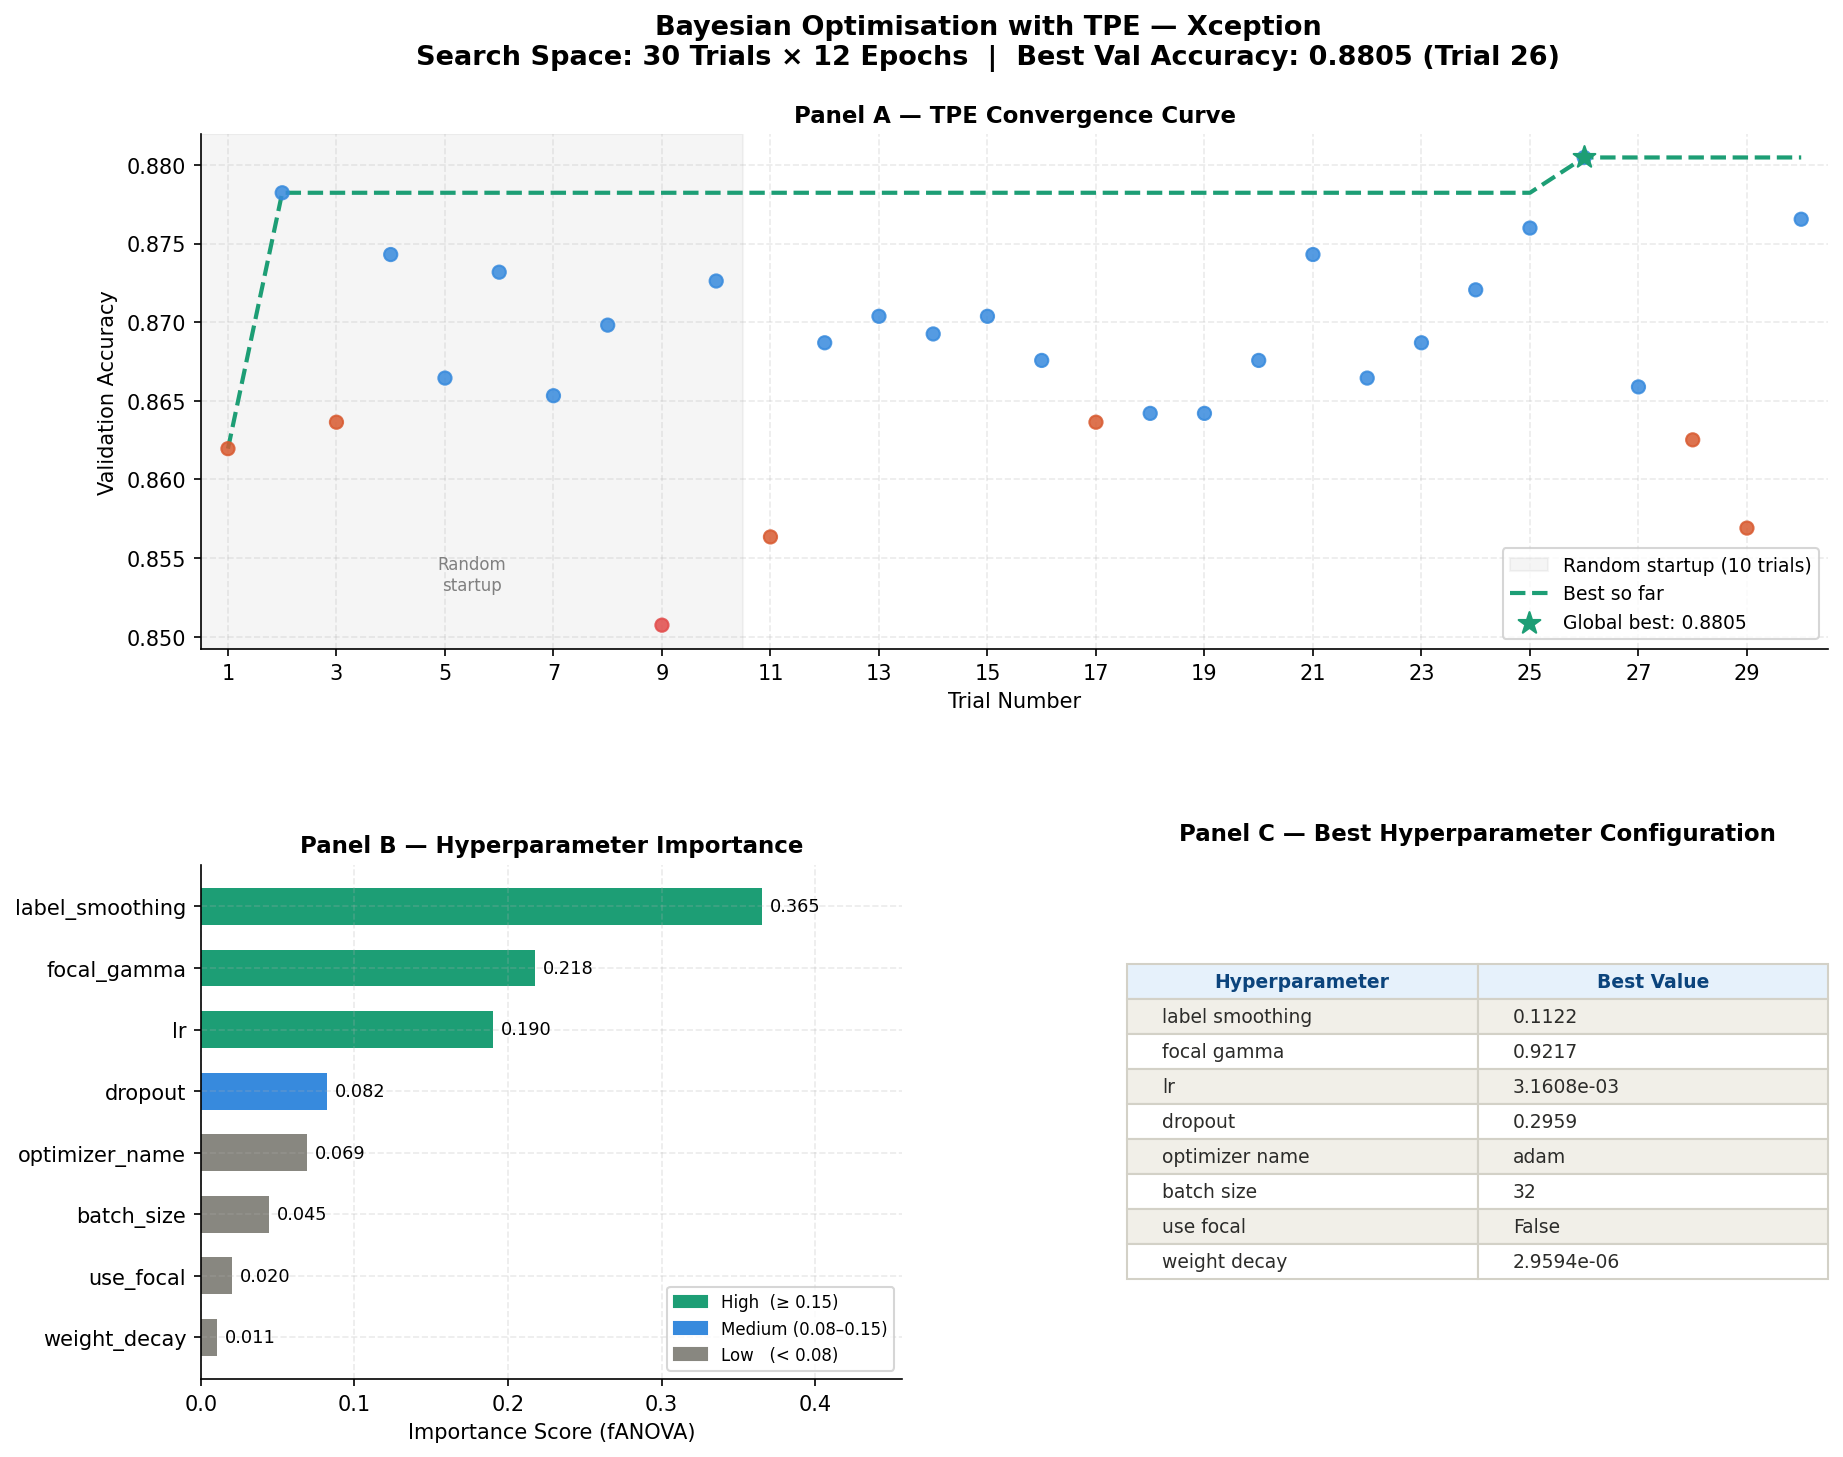

Figure saved: /kaggle/working/full_pipeline_results/tpe_analysis_xception.png

Hyperparameter Importance (Xception) — fANOVA:
  Hyperparameter         Importance  Rank
  ------------------------------------------
  label_smoothing            0.3653  #1  ██████████████████
  focal_gamma                0.2176  #2  ██████████
  lr                         0.1900  #3  █████████
  dropout                    0.0822  #4  ████
  optimizer_name             0.0692  #5  ███
  batch_size                 0.0446  #6  ██
  use_focal                  0.0204  #7  █
  weight_decay               0.0107  #8  


In [9]:
matplotlib.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.25,
    'grid.linestyle'   : '--',
    'figure.dpi'       : 150,
})

arch_name_viz = arch_name
label_viz     = MODEL_LABELS[arch_name_viz]

trial_values  = [t.value for t in study.trials if t.value is not None]
n_trials      = len(trial_values)
best_so_far   = [max(trial_values[:i+1]) for i in range(n_trials)]
trial_nums    = list(range(1, n_trials + 1))
best_val      = study.best_value
best_trial_n  = study.best_trial.number + 1

importance    = optuna.importance.get_param_importances(
    study,
    evaluator=optuna.importance.FanovaImportanceEvaluator())
hp_names      = list(importance.keys())
hp_scores     = list(importance.values())
sorted_pairs  = sorted(zip(hp_scores, hp_names), reverse=True)
hp_scores_s   = [p[0] for p in sorted_pairs]
hp_names_s    = [p[1] for p in sorted_pairs]

fig = plt.figure(figsize=(14, 10))
fig.suptitle(
    f'Bayesian Optimisation with TPE — {label_viz}\n'
    f'Search Space: {n_trials} Trials × {TPE_EPOCHS} Epochs  |  '
    f'Best Val Accuracy: {best_val:.4f} (Trial {best_trial_n})',
    fontsize=13, fontweight='bold', y=0.98)

gs  = gridspec.GridSpec(2, 2, figure=fig,
                        hspace=0.42, wspace=0.32,
                        top=0.90, bottom=0.07)

C_TRIAL  = '#378ADD'
C_BEST   = '#1D9E75'
C_WORST  = '#E24B4A'
C_START  = (0.533, 0.529, 0.502, 0.07)

ax1 = fig.add_subplot(gs[0, :])   # full-width top row

ax1.axvspan(0.5, TPE_WARMUP_TR + 0.5,
            alpha=0.08, color='gray',
            label=f'Random startup ({TPE_WARMUP_TR} trials)')

colors_dot = [C_WORST if v == min(trial_values) else
              ('#D85A30' if v < np.percentile(trial_values, 25) else C_TRIAL)
              for v in trial_values]
ax1.scatter(trial_nums, trial_values,
            c=colors_dot, s=40, zorder=4, alpha=0.85)

ax1.plot(trial_nums, best_so_far,
         color=C_BEST, linewidth=2, linestyle='--',
         label='Best so far', zorder=3)

ax1.scatter([best_trial_n], [best_val],
            color=C_BEST, s=120, zorder=5,
            marker='*', label=f'Global best: {best_val:.4f}')

ax1.text(TPE_WARMUP_TR / 2 + 0.5, min(trial_values) + 0.002,
         'Random\nstartup', fontsize=8, color='gray',
         ha='center', va='bottom')

ax1.set_xlabel('Trial Number', fontsize=10)
ax1.set_ylabel('Validation Accuracy', fontsize=10)
ax1.set_title('Panel A — TPE Convergence Curve', fontsize=11, fontweight='bold')
ax1.set_xlim(0.5, n_trials + 0.5)
ax1.set_xticks(range(1, n_trials + 1, 2))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
ax1.legend(fontsize=9, loc='lower right')

ax2 = fig.add_subplot(gs[1, 0])

bar_colors = ['#1D9E75' if s >= 0.15 else
              '#378ADD' if s >= 0.08 else
              '#888780' for s in hp_scores_s]

bars = ax2.barh(hp_names_s, hp_scores_s,
                color=bar_colors, height=0.6, edgecolor='none')

for bar, score in zip(bars, hp_scores_s):
    ax2.text(score + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{score:.3f}', va='center', ha='left', fontsize=8.5)

ax2.set_xlabel('Importance Score (fANOVA)', fontsize=10)
ax2.set_title('Panel B — Hyperparameter Importance', fontsize=11, fontweight='bold')
ax2.set_xlim(0, max(hp_scores_s) * 1.25)
ax2.invert_yaxis()

legend_patches = [
    mpatches.Patch(color='#1D9E75', label='High  (≥ 0.15)'),
    mpatches.Patch(color='#378ADD', label='Medium (0.08–0.15)'),
    mpatches.Patch(color='#888780', label='Low   (< 0.08)'),
]
ax2.legend(handles=legend_patches, fontsize=8, loc='lower right')

ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')

bp_disp = tpe_best_params[arch_name_viz]
rows = []
fmt  = {
    'lr'              : lambda v: f'{v:.4e}',
    'batch_size'      : lambda v: str(int(v)),
    'dropout'         : lambda v: f'{v:.4f}',
    'weight_decay'    : lambda v: f'{v:.4e}',
    'unfreeze_init'   : lambda v: str(v),
    'optimizer_name'  : lambda v: str(v),
    'use_focal'       : lambda v: str(v),
    'focal_gamma'     : lambda v: f'{v:.4f}',
    'label_smoothing' : lambda v: f'{v:.4f}',
    'scheduler_type'  : lambda v: str(v),
    'warmup_epochs'   : lambda v: str(int(v)),
    'layer_decay'     : lambda v: f'{v:.4f}',
}
for k, v in bp_disp.items():
    if k == 'best_val_acc':
        continue
    disp_v = fmt[k](v) if k in fmt else str(v)
    rows.append([k.replace('_', ' '), disp_v])

imp_rank = {k: i for i, k in enumerate(hp_names_s)}
rows.sort(key=lambda r: imp_rank.get(r[0].replace(' ', '_'), 99))

table = ax3.table(
    cellText  = rows,
    colLabels = ['Hyperparameter', 'Best Value'],
    loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('#D3D1C7')
    if r == 0:
        cell.set_facecolor('#E6F1FB')
        cell.set_text_props(fontweight='bold', color='#0C447C')
    else:
        cell.set_facecolor('#FFFFFF' if r % 2 == 0 else '#F1EFE8')
        cell.set_text_props(color='#2C2C2A')

ax3.set_title('Panel C — Best Hyperparameter Configuration',
              fontsize=11, fontweight='bold', pad=12)

out_path = OUTPUT_DIR / f'tpe_analysis_{arch_name_viz}.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"Figure saved: {out_path}")

print(f"\nHyperparameter Importance ({label_viz}) — fANOVA:")
print(f"  {'Hyperparameter':<22} {'Importance':>10}  {'Rank'}")
print("  " + "-" * 42)
for rank, (name, score) in enumerate(zip(hp_names_s, hp_scores_s), 1):
    bar = '█' * int(score * 50)
    print(f"  {name:<22} {score:>10.4f}  #{rank}  {bar}")